In [1]:
!pip install pyspark vaderSentiment -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, re, warnings, joblib
warnings.filterwarnings('ignore')

print("All libraries ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.8 MB/s eta 0:00:00
All libraries ready


In [3]:
from google.colab import files
uploaded = files.upload()
# A button will appear — click it and select reviews_clean.csv from your computer

Saving reviews_clean.csv to reviews_clean.csv


In [4]:
df = pd.read_csv('reviews_clean.csv')
df['Text'] = df['Text'].astype(str)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (524587, 16)
Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'year', 'month', 'sentiment', 'sentiment_label', 'text_length', 'word_count']

First 3 rows:


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,year,month,sentiment,sentiment_label,text_length,word_count
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,2011-04-27,Good Quality Dog Food,I have bought several of the Vitality canned d...,2011,4,positive,1,263,48
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,2012-09-07,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,2012,9,negative,0,190,31
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,2008-08-18,"""Delight"" says it all",This is a confection that has been around a fe...,2008,8,positive,1,509,94


In [5]:
# Text features
df['text_length']    = df['Text'].apply(len)
df['word_count']     = df['Text'].apply(lambda x: len(x.split()))
df['avg_word_len']   = df['Text'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
df['sentence_count'] = df['Text'].apply(
    lambda x: len([s for s in x.split('.') if s.strip()]))
df['exclamations']   = df['Text'].apply(lambda x: x.count('!'))
df['questions']      = df['Text'].apply(lambda x: x.count('?'))
df['caps_ratio']     = df['Text'].apply(
    lambda x: sum(1 for c in x if c.isupper())/len(x) if len(x) > 0 else 0)

# Summary feature — safe check
if 'Summary' in df.columns:
    df['has_summary'] = df['Summary'].apply(
        lambda x: int(len(str(x).strip()) > 0) if pd.notnull(x) else 0)
else:
    df['has_summary'] = 0
    print("No Summary column — set has_summary=0")

# Helpfulness feature — safe check
if 'HelpfulnessNumerator' in df.columns and 'HelpfulnessDenominator' in df.columns:
    df['helpfulness_ratio'] = df.apply(
        lambda r: r['HelpfulnessNumerator'] / r['HelpfulnessDenominator']
        if r['HelpfulnessDenominator'] > 0 else 0, axis=1)
else:
    df['helpfulness_ratio'] = 0
    print("No helpfulness columns — set helpfulness_ratio=0")

# Time features — safe check
if 'Time' in df.columns:
    df['Time']        = pd.to_datetime(df['Time'], errors='coerce')
    df['day_of_week'] = df['Time'].dt.dayofweek
    df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
    df['quarter']     = df['Time'].dt.quarter
elif 'year' in df.columns:
    df['day_of_week'] = 0
    df['is_weekend']  = 0
    df['quarter']     = 0
    print("No Time column — using existing year/month columns")
else:
    df['year']        = 2020
    df['month']       = 1
    df['day_of_week'] = 0
    df['is_weekend']  = 0
    df['quarter']     = 0

print("Features created successfully")
print("Shape:", df.shape)

Features created successfully
Shape: (524587, 26)


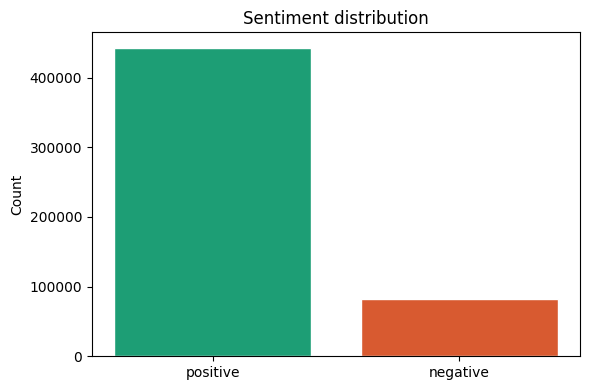

Positive: 442869 | Negative: 81718


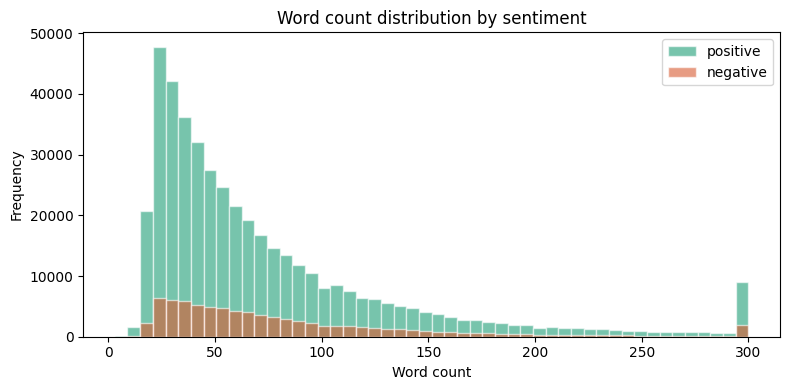


Avg word count by sentiment:
sentiment
negative    86.64
positive    77.10
Name: word_count, dtype: float64


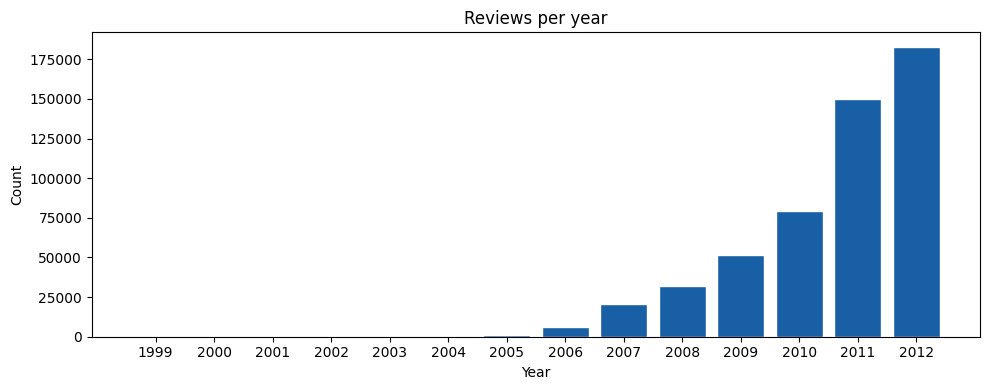

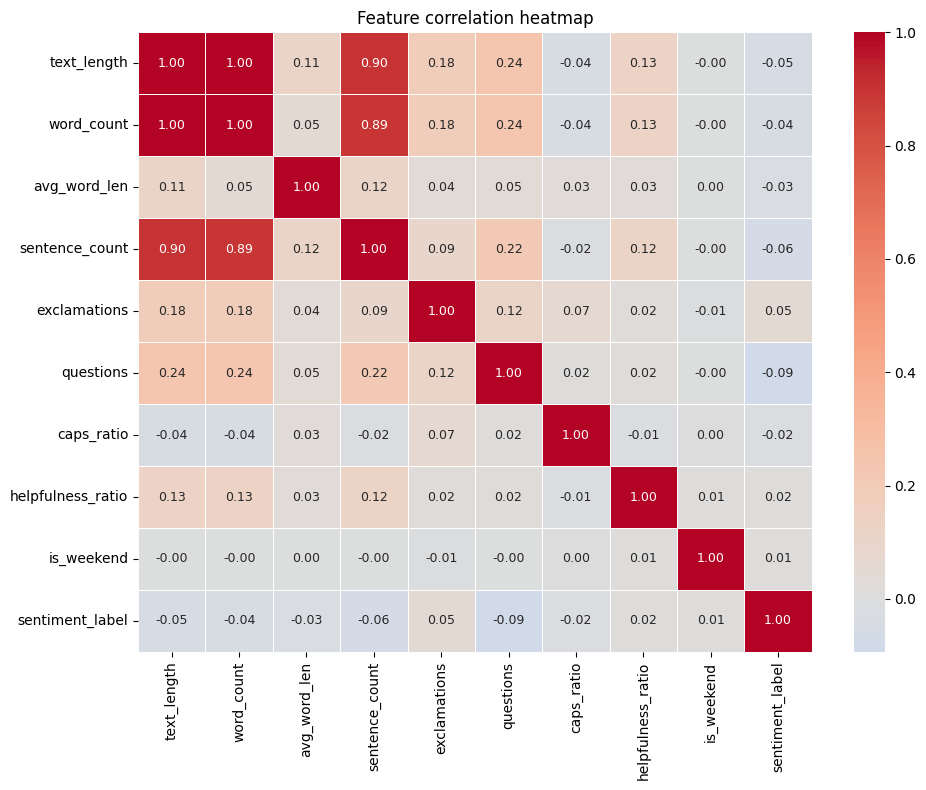


All EDA charts saved to figures/


In [6]:
os.makedirs('figures', exist_ok=True)

# Chart 1 — sentiment distribution
plt.figure(figsize=(6,4))
counts = df['sentiment'].value_counts()
colors = ['#1D9E75' if x=='positive' else '#D85A30' for x in counts.index]
plt.bar(counts.index, counts.values, color=colors, edgecolor='white')
plt.title('Sentiment distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('figures/sentiment_distribution.png', dpi=150)
plt.show()
print("Positive:", counts.get('positive', 0), "| Negative:", counts.get('negative', 0))

# Chart 2 — word count distribution
plt.figure(figsize=(8,4))
for label, color in [('positive','#1D9E75'), ('negative','#D85A30')]:
    subset = df[df['sentiment']==label]['word_count'].clip(upper=300)
    plt.hist(subset, bins=50, alpha=0.6, color=color, label=label, edgecolor='white')
plt.title('Word count distribution by sentiment')
plt.xlabel('Word count')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('figures/wordcount_distribution.png', dpi=150)
plt.show()

# Chart 3 — avg word count by sentiment
print("\nAvg word count by sentiment:")
print(df.groupby('sentiment')['word_count'].mean().round(2))

# Chart 4 — reviews per year
if 'year' in df.columns:
    plt.figure(figsize=(10,4))
    year_counts = df['year'].value_counts().sort_index()
    plt.bar(year_counts.index.astype(str), year_counts.values,
            color='#185FA5', edgecolor='white')
    plt.title('Reviews per year')
    plt.xlabel('Year')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig('figures/reviews_per_year.png', dpi=150)
    plt.show()

# Chart 5 — correlation heatmap
feature_cols = ['text_length','word_count','avg_word_len','sentence_count',
                'exclamations','questions','caps_ratio','helpfulness_ratio',
                'is_weekend','sentiment_label']
feature_cols = [c for c in feature_cols if c in df.columns and df[c].std() > 0]

plt.figure(figsize=(10,8))
sns.heatmap(df[feature_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, annot_kws={'size':9})
plt.title('Feature correlation heatmap')
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=150)
plt.show()

print("\nAll EDA charts saved to figures/")